# Bài toán Linear Regression theo phương pháp Gradient Descent

Trong Deep Learning, mô hình Linear Regression đơn biến có thể được coi là một mạng Neural đơn giản nhất (chỉ có 1 nơ-ron). Hàm dự đoán có dạng:
$$\hat{y} = wx + b$$

Trong đó:
* $x$ là dữ liệu đầu vào.
* $w$ (weight - trọng số) và $b$ (bias - độ lệch) là các tham số của mô hình cần được học.
* $\hat{y}$ là giá trị dự đoán.

Thay vì giải phương trình toán học để tìm nghiệm chính xác, ta sẽ cho máy tính đoán bừa $w$ và $b$ ban đầu, sau đó dùng thuật toán **Gradient Descent** để sửa sai dần dần dựa trên đạo hàm của hàm mất mát (Loss Function).

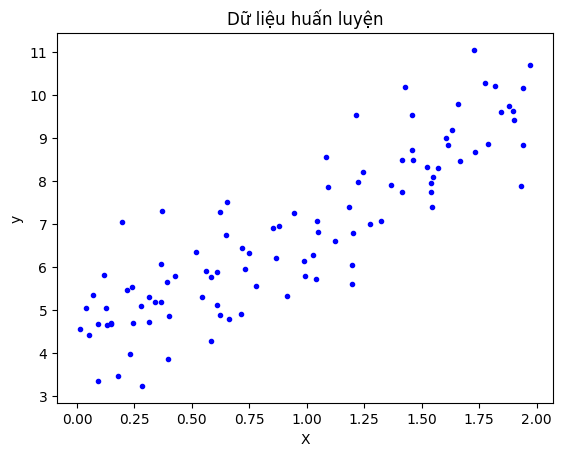

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo dữ liệu giả lập
# Giả sử hàm thực tế là y = 3x + 4, ta sẽ thêm một chút nhiễu
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # Thêm nhiễu Gauss

# Vẽ dữ liệu ra xem thử
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dữ liệu huấn luyện")
plt.show()

## Hàm mất mát (Loss Function) và cập nhật trọng số

Chúng ta sử dụng hàm **Mean Squared Error (MSE)** làm thước đo sai số:
$$L(w, b) = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)^2$$

Đạo hàm của hàm mất mát theo $w$ và $b$:
* $\frac{\partial L}{\partial w} = \frac{2}{N} \sum_{i=1}^N x_i(\hat{y}_i - y_i)$
* $\frac{\partial L}{\partial b} = \frac{2}{N} \sum_{i=1}^N (\hat{y}_i - y_i)$

Công thức cập nhật (Gradient Descent):
* $w = w - \eta \frac{\partial L}{\partial w}$
* $b = b - \eta \frac{\partial L}{\partial b}$

($\eta$ là learning rate - tốc độ học).

In [2]:
# Khởi tạo tham số w và b ngẫu nhiên
w = np.random.randn(1)
b = np.random.randn(1)

# Các siêu tham số (Hyperparameters)
learning_rate = 0.1
epochs = 100
N = len(X)

# Lưu lại lịch sử loss để vẽ đồ thị
loss_history = []

# Vòng lặp huấn luyện (Training loop)
for epoch in range(epochs):
    # 1. Tính toán giá trị dự đoán (Forward pass)
    y_hat = w * X + b

    # 2. Tính hàm mất mát MSE
    loss = (1/N) * np.sum((y_hat - y)**2)
    loss_history.append(loss)

    # 3. Tính đạo hàm (Gradients)
    dw = (2/N) * np.sum(X * (y_hat - y))
    db = (2/N) * np.sum(y_hat - y)

    # 4. Cập nhật trọng số (Gradient Descent)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # In kết quả sau mỗi 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}, w = {w[0]:.4f}, b = {b[0]:.4f}")

print(f"\nKết quả cuối cùng: w = {w[0]:.4f}, b = {b[0]:.4f}")
print("So sánh với hàm gốc (w=3, b=4), mô hình đã xấp xỉ rất tốt!")

Epoch 0: Loss = 32.1386, w = 1.2132, b = 2.5244
Epoch 20: Loss = 0.8091, w = 2.8487, b = 4.1260
Epoch 40: Loss = 0.8072, w = 2.8095, b = 4.1705
Epoch 60: Loss = 0.8067, w = 2.7899, b = 4.1927
Epoch 80: Loss = 0.8066, w = 2.7800, b = 4.2039

Kết quả cuối cùng: w = 2.7753, b = 4.2093
So sánh với hàm gốc (w=3, b=4), mô hình đã xấp xỉ rất tốt!


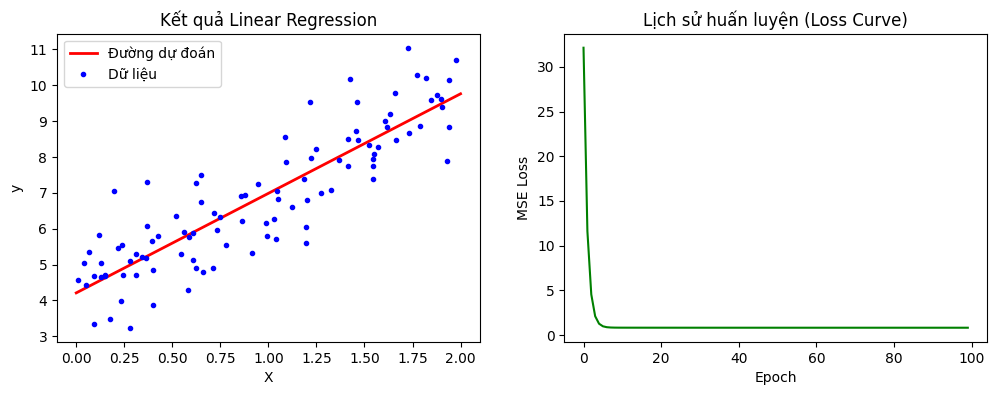

In [3]:
# Tạo dữ liệu để vẽ đường thẳng dự đoán
X_new = np.array([[0], [2]])
y_predict = w * X_new + b

# Vẽ đồ thị
plt.figure(figsize=(12, 4))

# Đồ thị 1: Đường hồi quy
plt.subplot(1, 2, 1)
plt.plot(X_new, y_predict, "r-", linewidth=2, label="Đường dự đoán")
plt.plot(X, y, "b.", label="Dữ liệu")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Kết quả Linear Regression")

# Đồ thị 2: Quá trình giảm Loss
plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss_history, "g-")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Lịch sử huấn luyện (Loss Curve)")

plt.show()